In [ ]:
# ==============================================================================
# ANÁLISE EXPLORATÓRIA - TABELA FIPE
# Disciplina: Estatística
# Dataset: fipex-prices-latest-merged.parquet
#
# IMPORTANTE: Esta análise utiliza um SNAPSHOT de um único mês de referência
# (Abril/2026) para garantir que cada veículo seja contado apenas uma vez,
# evitando distorções causadas por registros históricos repetidos.
# ==============================================================================

# --- 0. INSTALAÇÃO E CARREGAMENTO DE PACOTES ------------------------------------

install.packages(c("arrow", "dplyr", "ggplot2", "e1071", "scales", "tidyr"))

library(arrow)      # leitura de parquet
library(dplyr)      # manipulação de dados
library(ggplot2)    # visualizações
library(e1071)      # skewness e kurtosis
library(scales)     # formatação de eixos (R$, %)
library(tidyr)      # auxiliar para transformações

In [8]:
# --- 1. PRÉ-PROCESSAMENTO ----------------------------------------------------

# 1.1 Carregamento do arquivo parquet (dataset bruto completo)
df_bruto <- read_parquet("/content/fipex-prices-latest-merged.parquet")

# 1.2 Visão geral do dataset BRUTO (antes do filtro)
cat("===== DIMENSÕES DO DATASET BRUTO =====\n")
cat(sprintf("Linhas: %s  |  Colunas: %s\n", format(nrow(df_bruto), big.mark = "."),
            ncol(df_bruto)))
cat(sprintf("Anos disponíveis: %d a %d\n",
            min(df_bruto$ano_referencia), max(df_bruto$ano_referencia)))

cat("\n===== ESTRUTURA =====\n")
str(df_bruto)

# 1.3 Filtro temporal — SNAPSHOT de um único mês
# Justificativa: sem esse filtro, o mesmo veículo aparece repetido em cada mês,
# inflando contagens e misturando preços de épocas diferentes na mesma média.
ANO_REF <- 2026
MES_REF <- 4

df <- df_bruto %>%
  filter(ano_referencia == ANO_REF, mes_referencia == MES_REF)

cat(sprintf("\n===== FILTRO APLICADO: %02d/%d =====\n", MES_REF, ANO_REF))
cat(sprintf("Registros após filtro: %s (de %s originais)\n",
            format(nrow(df), big.mark = "."),
            format(nrow(df_bruto), big.mark = ".")))

# Liberar memória do dataset bruto (não será mais usado)
rm(df_bruto)
gc()

# 1.4 Criação da variável valor_reais
df <- df %>%
  mutate(valor_reais = valor_centavos / 100)

# 1.5 Verificação de valores ausentes
cat("\n===== VALORES AUSENTES POR COLUNA =====\n")
print(colSums(is.na(df)))

cat("\n===== PRIMEIRAS LINHAS (snapshot filtrado) =====\n")
print(head(df, 10))

===== DIMENSÕES DO DATASET BRUTO =====


Warning message in prettyNum(.Internal(format(x, trim, digits, nsmall, width, 3L, :
“'big.mark' and 'decimal.mark' are both '.', which could be confusing”


Linhas: 9.276.121  |  Colunas: 12
Anos disponíveis: 2001 a 2026

===== ESTRUTURA =====
tibble [9,276,121 × 12] (S3: tbl_df/tbl/data.frame)
 $ tipo_veiculo     : chr [1:9276121] "moto" "moto" "moto" "moto" ...
 $ codigo_fipe      : chr [1:9276121] "840015-6" "840015-6" "840015-6" "840015-6" ...
 $ nome_modelo      : chr [1:9276121] "ATV 100" "ATV 100" "ATV 100" "ATV 100" ...
 $ nome_marca       : chr [1:9276121] "ADLY" "ADLY" "ADLY" "ADLY" ...
 $ nome_combustivel : chr [1:9276121] "Gasolina" "Gasolina" "Gasolina" "Gasolina" ...
 $ sigla_combustivel: chr [1:9276121] "g" "g" "g" "g" ...
 $ ano_modelo       : int [1:9276121] 1990 1991 1992 1993 1994 1995 1996 1997 1998 1999 ...
 $ zero_km          : logi [1:9276121] FALSE FALSE FALSE FALSE FALSE FALSE ...
 $ valor_centavos   : int [1:9276121] 0 0 0 0 0 0 0 0 0 0 ...
 $ valor_formatado  : chr [1:9276121] "R$ 0,00" "R$ 0,00" "R$ 0,00" "R$ 0,00" ...
 $ mes_referencia   : int [1:9276121] 9 9 9 9 9 9 9 9 9 9 ...
 $ ano_referencia   : int [1:927

Warning message in prettyNum(.Internal(format(x, trim, digits, nsmall, width, 3L, :
“'big.mark' and 'decimal.mark' are both '.', which could be confusing”
Warning message in prettyNum(.Internal(format(x, trim, digits, nsmall, width, 3L, :
“'big.mark' and 'decimal.mark' are both '.', which could be confusing”


Registros após filtro: 50.129 (de 9.276.121 originais)


,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,1975712,105.6,4029388,215.2,4029388,215.2
Vcells,7402512,56.5,91080452,694.9,177827163,1356.8



===== VALORES AUSENTES POR COLUNA =====
     tipo_veiculo       codigo_fipe       nome_modelo        nome_marca 
                0                 0                 0                 0 
 nome_combustivel sigla_combustivel        ano_modelo           zero_km 
                0                 0              1829                 0 
   valor_centavos   valor_formatado    mes_referencia    ano_referencia 
                0                 0                 0                 0 
      valor_reais 
                0 

===== PRIMEIRAS LINHAS (snapshot filtrado) =====
# A tibble: 10 × 13
   tipo_veiculo codigo_fipe nome_modelo   nome_marca nome_combustivel
   <chr>        <chr>       <chr>         <chr>      <chr>           
 1 moto         840015-6    ATV 100       ADLY       Gasolina        
 2 moto         840015-6    ATV 100       ADLY       Gasolina        
 3 moto         840015-6    ATV 100       ADLY       Gasolina        
 4 moto         840014-8    ATV 50        ADLY       Gasolina  

In [5]:
# --- 2. ESTATÍSTICA DESCRITIVA (variável: valor_reais) ------------------------
# Todas as estatísticas abaixo referem-se ao snapshot de um único mês,
# ou seja, cada veículo/modelo é contado exatamente uma vez.

# Função auxiliar para calcular a moda
calc_moda <- function(x) {
  x <- na.omit(x)
  ux <- unique(x)
  ux[which.max(tabulate(match(x, ux)))]
}

cat("\n\n")
cat("================================================================\n")
cat(sprintf("  ESTATÍSTICAS DESCRITIVAS — valor_reais (R$) — %02d/%d\n", MES_REF, ANO_REF))
cat("================================================================\n\n")

# 2.1 Medidas de tendência central
media   <- mean(df$valor_reais, na.rm = TRUE)
mediana <- median(df$valor_reais, na.rm = TRUE)
moda    <- calc_moda(df$valor_reais)

cat("--- Medidas de Tendência Central ---\n")
cat(sprintf("  Média ....... R$ %s\n",   format(round(media, 2),   big.mark = ".", decimal.mark = ",")))
cat(sprintf("  Mediana ..... R$ %s\n",   format(round(mediana, 2), big.mark = ".", decimal.mark = ",")))
cat(sprintf("  Moda ........ R$ %s\n\n", format(round(moda, 2),    big.mark = ".", decimal.mark = ",")))

# 2.2 Medidas de dispersão
variancia   <- var(df$valor_reais, na.rm = TRUE)
desvio_pad  <- sd(df$valor_reais, na.rm = TRUE)

cat("--- Medidas de Dispersão ---\n")
cat(sprintf("  Variância ... %s\n",   format(round(variancia, 2), big.mark = ".", decimal.mark = ",")))
cat(sprintf("  Desvio Padrão R$ %s\n\n", format(round(desvio_pad, 2), big.mark = ".", decimal.mark = ",")))

# 2.3 Medidas de forma
assimetria <- skewness(df$valor_reais, na.rm = TRUE)
curtose    <- kurtosis(df$valor_reais, na.rm = TRUE)

cat("--- Medidas de Forma ---\n")
cat(sprintf("  Assimetria (Skewness) ... %s\n", round(assimetria, 4)))
cat(sprintf("  Curtose (Kurtosis) ...... %s\n\n", round(curtose, 4)))

# 2.4 Medidas de posição (quartis e percentis)
quartis   <- quantile(df$valor_reais, probs = c(0.25, 0.50, 0.75), na.rm = TRUE)
percentis <- quantile(df$valor_reais, probs = c(0.10, 0.90), na.rm = TRUE)

cat("--- Quartis ---\n")
cat(sprintf("  Q1 (25%%) .... R$ %s\n", format(round(quartis[1], 2), big.mark = ".", decimal.mark = ",")))
cat(sprintf("  Q2 (50%%) .... R$ %s\n", format(round(quartis[2], 2), big.mark = ".", decimal.mark = ",")))
cat(sprintf("  Q3 (75%%) .... R$ %s\n\n", format(round(quartis[3], 2), big.mark = ".", decimal.mark = ",")))

cat("--- Percentis ---\n")
cat(sprintf("  P10 (10%%) ... R$ %s\n", format(round(percentis[1], 2), big.mark = ".", decimal.mark = ",")))
cat(sprintf("  P90 (90%%) ... R$ %s\n", format(round(percentis[2], 2), big.mark = ".", decimal.mark = ",")))

# 2.5 Estatísticas por tipo de veículo
# Essa segmentação é fundamental porque misturar carros, motos e caminhões
# distorce a média geral (um caminhão de R$ 800k "puxa" a média para cima).
cat("\n\n===== ESTATÍSTICAS POR TIPO DE VEÍCULO =====\n")
stats_tipo <- df %>%
  group_by(tipo_veiculo) %>%
  summarise(
    n           = n(),
    media       = mean(valor_reais, na.rm = TRUE),
    mediana     = median(valor_reais, na.rm = TRUE),
    desvio_pad  = sd(valor_reais, na.rm = TRUE),
    minimo      = min(valor_reais, na.rm = TRUE),
    maximo      = max(valor_reais, na.rm = TRUE),
    q1          = quantile(valor_reais, 0.25, na.rm = TRUE),
    q3          = quantile(valor_reais, 0.75, na.rm = TRUE),
    .groups     = "drop"
  )
print(stats_tipo)



  ESTATÍSTICAS DESCRITIVAS — valor_reais (R$) — 04/2026

--- Medidas de Tendência Central ---
  Média ....... R$ 155.446,7
  Mediana ..... R$ 56.840
  Moda ........ R$ 9.430

--- Medidas de Dispersão ---
  Variância ... 130.676.509.830
  Desvio Padrão R$ 361.492,1

--- Medidas de Forma ---
  Assimetria (Skewness) ... 9.9373
  Curtose (Kurtosis) ...... 152.0087

--- Quartis ---
  Q1 (25%) .... R$ 24.435
  Q2 (50%) .... R$ 56.840
  Q3 (75%) .... R$ 148.311

--- Percentis ---
  P10 (10%) ... R$ 10.371,6
  P90 (90%) ... R$ 367.401,8


===== ESTATÍSTICAS POR TIPO DE VEÍCULO =====
# A tibble: 3 × 9
  tipo_veiculo     n   media mediana desvio_pad minimo  maximo     q1      q3
  <chr>        <int>   <dbl>   <dbl>      <dbl>  <dbl>   <dbl>  <dbl>   <dbl>
1 caminhão     11352 261634. 161215     262922.   4908 1516236 70369. 362920.
2 carro        29998 150731.  53480.    428041.   1787 9603000 24153. 124561.
3 moto          8779  34252.  22865      37341.    882  476063  8980.  46976.


Warning message in prettyNum(.Internal(format(x, trim, digits, nsmall, width, 3L, :
“'big.mark' and 'decimal.mark' are both '.', which could be confusing”
Warning message in prettyNum(.Internal(format(x, trim, digits, nsmall, width, 3L, :
“'big.mark' and 'decimal.mark' are both '.', which could be confusing”


Gráfico 1 salvo: grafico1_histograma.png


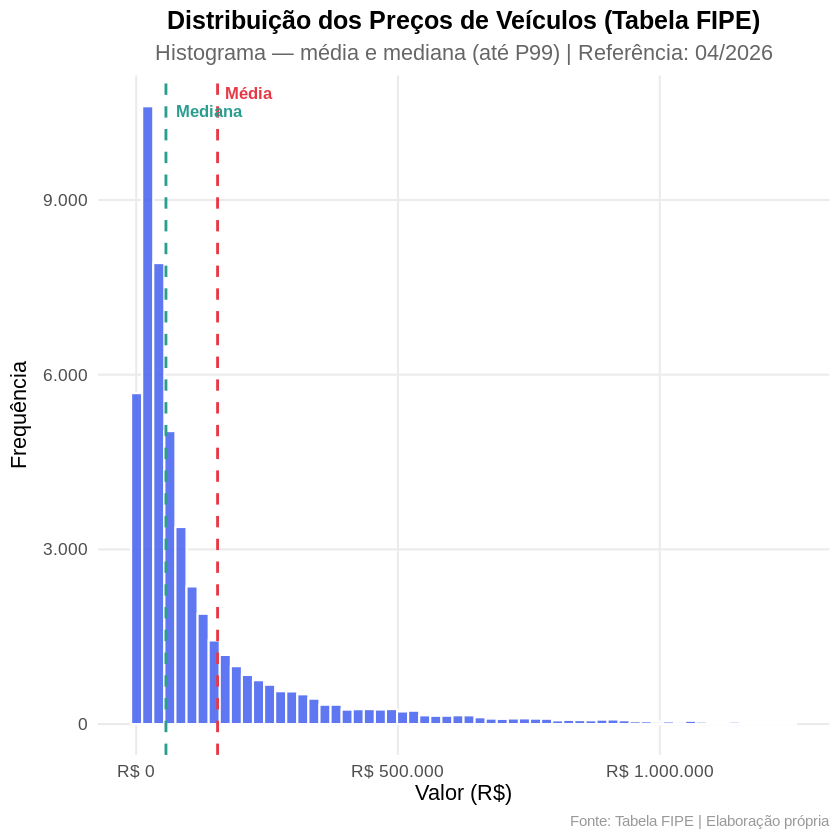

Gráfico 2 salvo: grafico2_boxplot.png


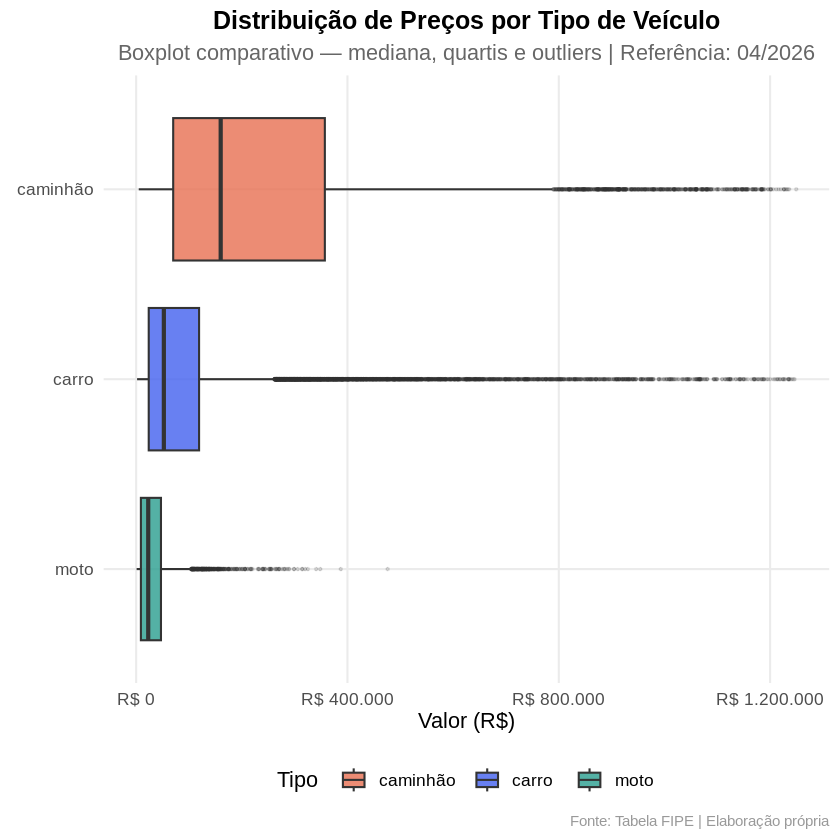

Gráfico 3 salvo: grafico3_combustivel.png


Warning message in prettyNum(.Internal(format(x, trim, digits, nsmall, width, 3L, :
“'big.mark' and 'decimal.mark' are both '.', which could be confusing”
Warning message in prettyNum(.Internal(format(x, trim, digits, nsmall, width, 3L, :
“'big.mark' and 'decimal.mark' are both '.', which could be confusing”


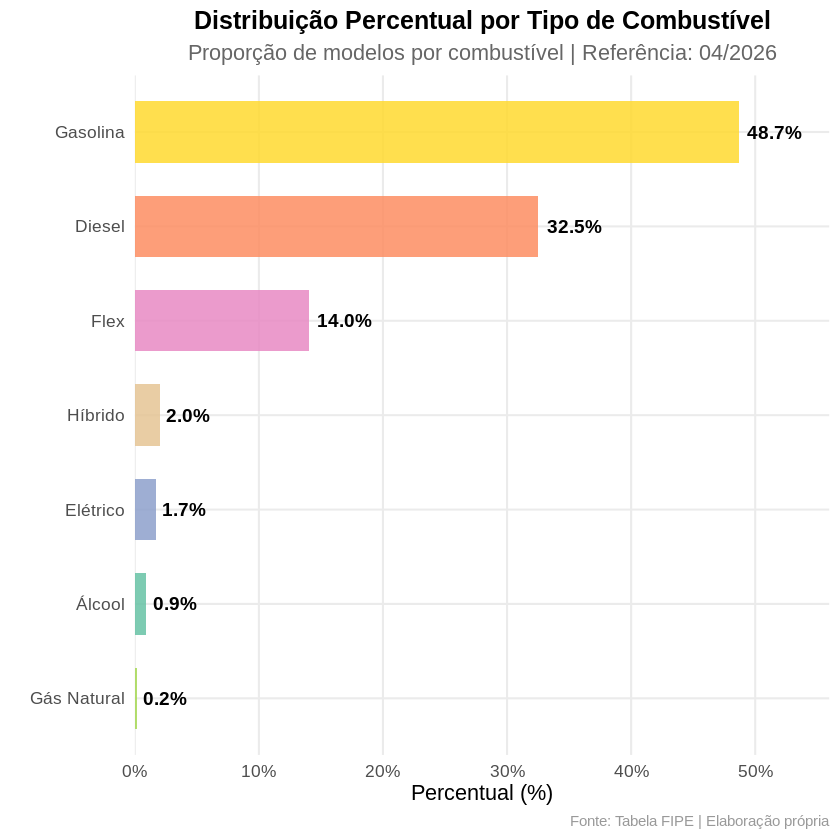

Warning message in prettyNum(.Internal(format(x, trim, digits, nsmall, width, 3L, :
“'big.mark' and 'decimal.mark' are both '.', which could be confusing”
Warning message in prettyNum(.Internal(format(x, trim, digits, nsmall, width, 3L, :
“'big.mark' and 'decimal.mark' are both '.', which could be confusing”


Gráfico 4 (bônus) salvo: grafico4_top_marcas.png

===== ANÁLISE CONCLUÍDA COM SUCESSO =====


Warning message in prettyNum(.Internal(format(x, trim, digits, nsmall, width, 3L, :
“'big.mark' and 'decimal.mark' are both '.', which could be confusing”


Snapshot utilizado: 04/2026 | Total de modelos analisados: 50.129


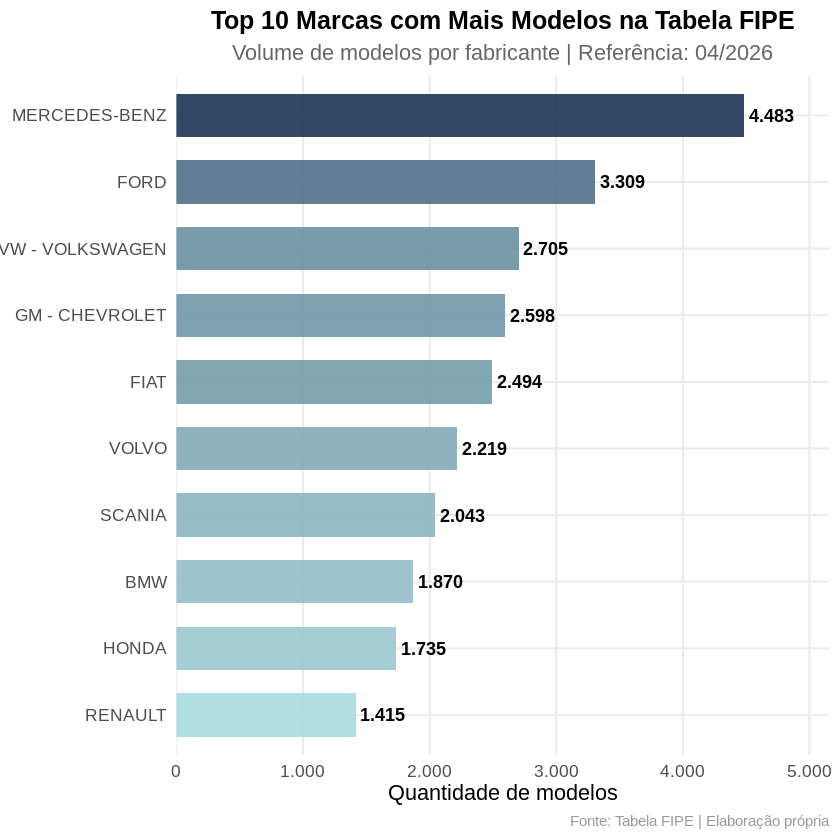

In [7]:
# --- 3. VISUALIZAÇÕES ---------------------------------------------------------
# Com ~50 mil registros (snapshot de um mês), não é necessário amostragem.
# Todos os gráficos usam o dataset filtrado completo.

# Tema visual customizado para todos os gráficos
tema_fipe <- theme_minimal(base_size = 13) +
  theme(
    plot.title    = element_text(face = "bold", size = 15, hjust = 0.5),
    plot.subtitle = element_text(color = "grey40", hjust = 0.5),
    plot.caption  = element_text(color = "grey60", size = 9),
    panel.grid.minor = element_blank(),
    legend.position  = "bottom"
  )

# Rótulo do mês para subtítulos
rotulo_ref <- sprintf("Referência: %02d/%d", MES_REF, ANO_REF)

# ---- GRÁFICO 1: Histograma da distribuição de valor_reais -------------------
# Filtramos até o P99 para evitar que outliers extremos achatem o gráfico.
# Nota: esse corte é APENAS visual; as estatísticas da Seção 2 usam 100% dos dados.
limite_sup <- quantile(df$valor_reais, 0.99, na.rm = TRUE)

g1 <- df %>%
  filter(valor_reais <= limite_sup) %>%
  ggplot(aes(x = valor_reais)) +
  geom_histogram(
    bins = 60,
    fill = "#4361EE",
    color = "white",
    alpha = 0.85
  ) +
  geom_vline(aes(xintercept = media),   color = "#E63946", linetype = "dashed", linewidth = 0.8) +
  geom_vline(aes(xintercept = mediana), color = "#2A9D8F", linetype = "dashed", linewidth = 0.8) +
  annotate("text", x = media,   y = Inf, label = "Média",   vjust = 2, hjust = -0.15, color = "#E63946", fontface = "bold", size = 3.5) +
  annotate("text", x = mediana, y = Inf, label = "Mediana", vjust = 3.5, hjust = -0.15, color = "#2A9D8F", fontface = "bold", size = 3.5) +
  scale_x_continuous(labels = label_dollar(prefix = "R$ ", big.mark = ".", decimal.mark = ",")) +
  scale_y_continuous(labels = label_comma(big.mark = ".")) +
  labs(
    title    = "Distribuição dos Preços de Veículos (Tabela FIPE)",
    subtitle = paste("Histograma — média e mediana (até P99) |", rotulo_ref),
    x = "Valor (R$)",
    y = "Frequência",
    caption  = "Fonte: Tabela FIPE | Elaboração própria"
  ) +
  tema_fipe

print(g1)

# Salva o gráfico
ggsave("grafico1_histograma.png", g1, width = 10, height = 6, dpi = 150)
cat("Gráfico 1 salvo: grafico1_histograma.png\n")


# ---- GRÁFICO 2: Boxplot por tipo_veiculo ------------------------------------

g2 <- df %>%
  filter(valor_reais <= limite_sup) %>%
  ggplot(aes(x = reorder(tipo_veiculo, valor_reais, FUN = median),
             y = valor_reais,
             fill = tipo_veiculo)) +
  geom_boxplot(
    outlier.alpha = 0.15,
    outlier.size  = 0.6,
    alpha = 0.8
  ) +
  scale_y_continuous(labels = label_dollar(prefix = "R$ ", big.mark = ".", decimal.mark = ",")) +
  scale_fill_manual(values = c("carro" = "#4361EE", "moto" = "#2A9D8F", "caminhão" = "#E76F51")) +
  coord_flip() +
  labs(
    title    = "Distribuição de Preços por Tipo de Veículo",
    subtitle = paste("Boxplot comparativo — mediana, quartis e outliers |", rotulo_ref),
    x = NULL,
    y = "Valor (R$)",
    fill = "Tipo",
    caption = "Fonte: Tabela FIPE | Elaboração própria"
  ) +
  tema_fipe

print(g2)
ggsave("grafico2_boxplot.png", g2, width = 10, height = 5, dpi = 150)
cat("Gráfico 2 salvo: grafico2_boxplot.png\n")


# ---- GRÁFICO 3: Distribuição percentual por tipo de combustível ---------------

df_combustivel <- df %>%
  count(nome_combustivel) %>%
  mutate(
    pct = n / sum(n) * 100,
    label = sprintf("%s\n(%.1f%%)", nome_combustivel, pct)
  ) %>%
  arrange(desc(pct))

g3 <- df_combustivel %>%
  ggplot(aes(x = reorder(nome_combustivel, pct), y = pct, fill = nome_combustivel)) +
  geom_col(alpha = 0.85, width = 0.65) +
  geom_text(aes(label = sprintf("%.1f%%", pct)), hjust = -0.15, size = 4, fontface = "bold") +
  scale_y_continuous(expand = expansion(mult = c(0, 0.15)), labels = function(x) paste0(x, "%")) +
  scale_fill_brewer(palette = "Set2") +
  coord_flip() +
  labs(
    title    = "Distribuição Percentual por Tipo de Combustível",
    subtitle = paste("Proporção de modelos por combustível |", rotulo_ref),
    x = NULL,
    y = "Percentual (%)",
    caption = "Fonte: Tabela FIPE | Elaboração própria"
  ) +
  tema_fipe +
  theme(legend.position = "none")

print(g3)
ggsave("grafico3_combustivel.png", g3, width = 10, height = 5, dpi = 150)
cat("Gráfico 3 salvo: grafico3_combustivel.png\n")


# ---- GRÁFICO BÔNUS: Top 10 marcas por volume --------------------------------

# Normalização de nomes de marca (resolve duplicatas por capitalização)
df <- df %>% mutate(nome_marca = toupper(nome_marca))

top10_marcas <- df %>%
  count(nome_marca, sort = TRUE) %>%
  slice_head(n = 10)

g4 <- top10_marcas %>%
  ggplot(aes(x = reorder(nome_marca, n), y = n, fill = n)) +
  geom_col(alpha = 0.9, width = 0.65) +
  geom_text(aes(label = format(n, big.mark = ".")), hjust = -0.1, size = 3.8, fontface = "bold") +
  scale_y_continuous(expand = expansion(mult = c(0, 0.15)), labels = label_comma(big.mark = ".")) +
  scale_fill_gradient(low = "#A8DADC", high = "#1D3557") +
  coord_flip() +
  labs(
    title    = "Top 10 Marcas com Mais Modelos na Tabela FIPE",
    subtitle = paste("Volume de modelos por fabricante |", rotulo_ref),
    x = NULL,
    y = "Quantidade de modelos",
    caption = "Fonte: Tabela FIPE | Elaboração própria"
  ) +
  tema_fipe +
  theme(legend.position = "none")

print(g4)
ggsave("grafico4_top_marcas.png", g4, width = 10, height = 5, dpi = 150)
cat("Gráfico 4 (bônus) salvo: grafico4_top_marcas.png\n")

cat("\n===== ANÁLISE CONCLUÍDA COM SUCESSO =====\n")
cat(sprintf("Snapshot utilizado: %02d/%d | Total de modelos analisados: %s\n",
            MES_REF, ANO_REF, format(nrow(df), big.mark = ".")))